In [2]:
import numpy as np
import matplotlib.pyplot as plt

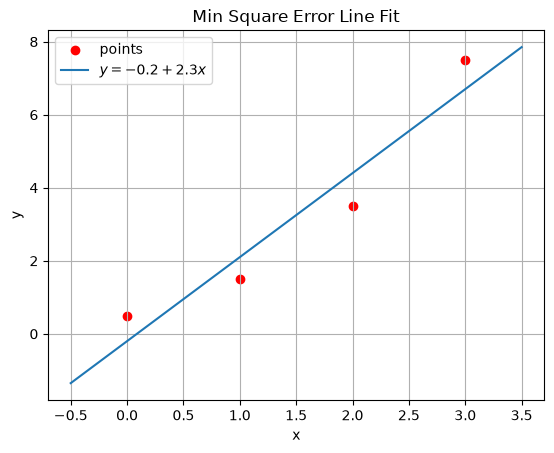

In [3]:
points = [(0,0.5),(2,3.5),(1,1.5),(3,7.5)]
xs, ys = zip(*points)

y = lambda x : -0.2 + 2.3 * x

x = np.linspace(-0.5, 3.5, 200)

plt.scatter(xs, ys, color="red", label="points")
plt.plot(x, y(x), label="$y = -0.2 + 2.3x$")
plt.title(f"Min Square Error Line Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)

plt.savefig(
    "media/line_fit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

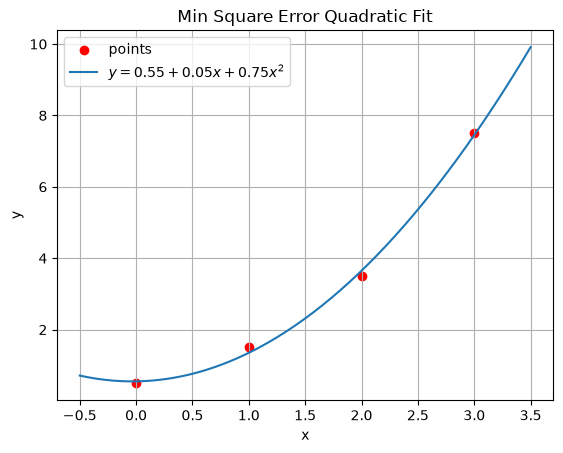

In [4]:
points = [(0,0.5),(2,3.5),(1,1.5),(3,7.5)]
xs, ys = zip(*points)

y = lambda x : 0.55 + 0.05 * x + 0.75 * x**2

x = np.linspace(-0.5, 3.5, 200)

plt.scatter(xs, ys, color="red", label="points")
plt.plot(x, y(x), label="$y = 0.55 + 0.05x + 0.75x^2$")
plt.title(f"Min Square Error Quadratic Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)

plt.savefig(
    "media/quadratic_fit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
def newton_raphson(c, d1, d2, tolerance=1e-7):

    iterations = [c.copy()]  # Iteration 0

    while True:
        old_c = c.copy()

        # Optimize c0 using current c1
        c[0] = c[0] - d1[0](c) / d2[0](c)

        # Optimize c1 using the new c0
        c[1] = c[1] - d1[1](c) / d2[1](c)

        iterations.append(c.copy())

        if np.linalg.norm(c - old_c) < tolerance:
            break

    return c, iterations

In [20]:
def d1_c0(c):
    c0, c1 = c
    return 8*c0 + 12*c1 - 26

def d2_c0(c):
    return 8

def d1_c1(c):
    c0, c1 = c
    return 12*c0 + 28*c1 - 62

def d2_c1(c):
    return 28

c = np.array([0.0, 0.0])

c, iterations = newton_raphson(
    c,
    [d1_c0, d1_c1],
    [d2_c0, d2_c1]
)

for i, values in enumerate(iterations, 1):
    print(
        f"Iteration {i}: "
        + ", ".join(f"c{j} = {values[j]:.6f}" for j in range(len(values)))
    )

Iteration 1: c0 = 0.000000, c1 = 0.000000
Iteration 2: c0 = 3.250000, c1 = 0.821429
Iteration 3: c0 = 2.017857, c1 = 1.349490
Iteration 4: c0 = 1.225765, c1 = 1.688958
Iteration 5: c0 = 0.716563, c1 = 1.907187
Iteration 6: c0 = 0.389219, c1 = 2.047477
Iteration 7: c0 = 0.178784, c1 = 2.137664
Iteration 8: c0 = 0.043504, c1 = 2.195641
Iteration 9: c0 = -0.043462, c1 = 2.232912
Iteration 10: c0 = -0.099368, c1 = 2.256872
Iteration 11: c0 = -0.135308, c1 = 2.272275
Iteration 12: c0 = -0.158412, c1 = 2.282177
Iteration 13: c0 = -0.173265, c1 = 2.288542
Iteration 14: c0 = -0.182813, c1 = 2.292634
Iteration 15: c0 = -0.188951, c1 = 2.295265
Iteration 16: c0 = -0.192897, c1 = 2.296956
Iteration 17: c0 = -0.195434, c1 = 2.298043
Iteration 18: c0 = -0.197065, c1 = 2.298742
Iteration 19: c0 = -0.198113, c1 = 2.299191
Iteration 20: c0 = -0.198787, c1 = 2.299480
Iteration 21: c0 = -0.199220, c1 = 2.299666
Iteration 22: c0 = -0.199499, c1 = 2.299785
Iteration 23: c0 = -0.199678, c1 = 2.299862
Itera

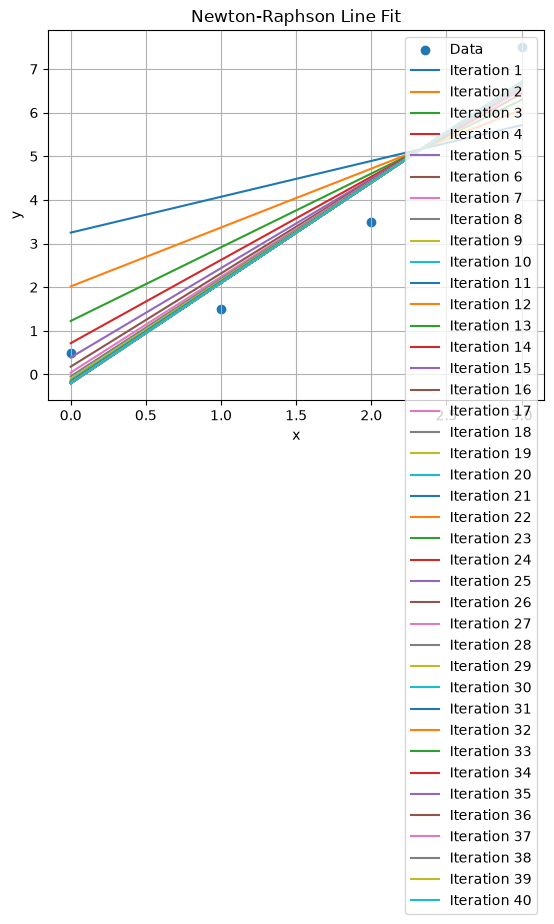

In [ ]:
x_line = np.linspace(min(xs), max(xs), 100)

plt.scatter(xs, ys, label="Data")

for i, values in enumerate(iterations):
    y_line = values[0] + values[1] * x_line
    plt.plot(x_line, y_line, label=f"Iteration {i}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Newton-Raphson Line Fit")
plt.legend()
plt.grid()
plt.show()